In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.model_selection import KFold, StratifiedKFold

In [4]:
wine = load_wine(as_frame=True)

df = wine.frame

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  target          

In [6]:
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [8]:
X = df.drop("target", axis=1)
y = df["target"]

print("Размер X:", X.shape)
print("Размер y:", y.shape)


Размер X: (178, 13)
Размер y: (178,)


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Обучающая выборка:", X_train.shape)
print("Тестовая выборка:", X_test.shape)

Обучающая выборка: (142, 13)
Тестовая выборка: (36, 13)


In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

accuracy_base = accuracy_score(y_test, y_pred)

print("Accuracy базовой модели:", accuracy_base)

Accuracy базовой модели: 0.9722222222222222


In [13]:
print("Матрица ошибок:")
print(confusion_matrix(y_test, y_pred))

print("\nОтчет классификации:")
print(classification_report(y_test, y_pred))

Матрица ошибок:
[[12  0  0]
 [ 0 13  1]
 [ 0  0 10]]

Отчет классификации:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      0.93      0.96        14
           2       0.91      1.00      0.95        10

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36



In [14]:
param_grid = {
    "n_neighbors": range(1, 31)
}

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search_kfold = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=kfold,
    scoring="accuracy"
)

grid_search_kfold.fit(X_train_scaled, y_train)

print("Лучший параметр K:", grid_search_kfold.best_params_)
print("Лучшее качество на кросс-валидации:", grid_search_kfold.best_score_)

Лучший параметр K: {'n_neighbors': 24}
Лучшее качество на кросс-валидации: 0.9790640394088669


In [15]:
stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search_stratified = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=stratified_kfold,
    scoring="accuracy"
)

grid_search_stratified.fit(X_train_scaled, y_train)

print("Лучший параметр K:", grid_search_stratified.best_params_)
print("Лучшее качество на кросс-валидации:", grid_search_stratified.best_score_)

Лучший параметр K: {'n_neighbors': 20}
Лучшее качество на кросс-валидации: 0.9788177339901478


In [16]:
param_dist = {
    "n_neighbors": range(1, 31)
}

random_search_kfold = RandomizedSearchCV(
    KNeighborsClassifier(),
    param_distributions=param_dist,
    n_iter=10,
    cv=kfold,
    scoring="accuracy",
    random_state=42
)

random_search_kfold.fit(X_train_scaled, y_train)

print("Лучший параметр K:", random_search_kfold.best_params_)
print("Лучшее качество на кросс-валидации:", random_search_kfold.best_score_)

Лучший параметр K: {'n_neighbors': 24}
Лучшее качество на кросс-валидации: 0.9790640394088669


In [17]:
random_search_stratified = RandomizedSearchCV(
    KNeighborsClassifier(),
    param_distributions=param_dist,
    n_iter=10,
    cv=stratified_kfold,
    scoring="accuracy",
    random_state=42
)

random_search_stratified.fit(X_train_scaled, y_train)

print("Лучший параметр K:", random_search_stratified.best_params_)
print("Лучшее качество на кросс-валидации:", random_search_stratified.best_score_)

Лучший параметр K: {'n_neighbors': 28}
Лучшее качество на кросс-валидации: 0.9716748768472907


In [18]:
best_k = grid_search_stratified.best_params_["n_neighbors"]

best_knn = KNeighborsClassifier(n_neighbors=best_k)

best_knn.fit(X_train_scaled, y_train)

y_pred_best = best_knn.predict(X_test_scaled)

accuracy_best = accuracy_score(y_test, y_pred_best)

print("Лучший K:", best_k)
print("Accuracy оптимальной модели:", accuracy_best)

Лучший K: 20
Accuracy оптимальной модели: 1.0


In [19]:
print("Матрица ошибок:")
print(confusion_matrix(y_test, y_pred_best))

print("\nОтчет классификации:")
print(classification_report(y_test, y_pred_best))

Матрица ошибок:
[[12  0  0]
 [ 0 14  0]
 [ 0  0 10]]

Отчет классификации:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



In [20]:
results = pd.DataFrame({
    "Модель": ["Базовая KNN", "Оптимальная KNN"],
    "K": [5, best_k],
    "Accuracy": [accuracy_base, accuracy_best]
})

results

,Модель,K,Accuracy
0,Базовая KNN,5,0.972222
1,Оптимальная KNN,20,1.000000


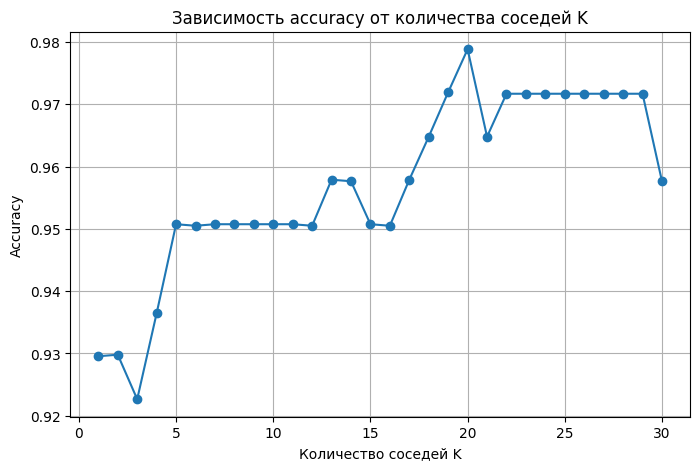

In [21]:
mean_scores = grid_search_stratified.cv_results_["mean_test_score"]
k_values = list(param_grid["n_neighbors"])

plt.figure(figsize=(8, 5))
plt.plot(k_values, mean_scores, marker="o")
plt.title("Зависимость accuracy от количества соседей K")
plt.xlabel("Количество соседей K")
plt.ylabel("Accuracy")
plt.grid()
plt.show()

In [22]:
print("""
По результатам эксперимента базовая модель KNN с параметром K = 5 показала accuracy = 0.9722.
После подбора гиперпараметра K с использованием GridSearchCV и StratifiedKFold
лучшим оказалось значение K = 20.

Оптимальная модель с K = 20 показала accuracy = 1.0 на тестовой выборке.
Матрица ошибок показывает, что все объекты тестовой выборки были классифицированы правильно.

Таким образом, подбор гиперпараметра K позволил улучшить качество модели:
accuracy увеличилась с 0.9722 до 1.0.
График зависимости accuracy от количества соседей показывает, что качество модели
изменяется при разных значениях K, поэтому подбор данного гиперпараметра является важным этапом.
""")


По результатам эксперимента базовая модель KNN с параметром K = 5 показала accuracy = 0.9722.
После подбора гиперпараметра K с использованием GridSearchCV и StratifiedKFold
лучшим оказалось значение K = 20.

Оптимальная модель с K = 20 показала accuracy = 1.0 на тестовой выборке.
Матрица ошибок показывает, что все объекты тестовой выборки были классифицированы правильно.

Таким образом, подбор гиперпараметра K позволил улучшить качество модели:
accuracy увеличилась с 0.9722 до 1.0.
График зависимости accuracy от количества соседей показывает, что качество модели
изменяется при разных значениях K, поэтому подбор данного гиперпараметра является важным этапом.

